# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

In this exercise, we  will generate random numbers from the continuous disributions we learned in the lesson. There are two ways to generate random numbers:

1. Using the numpy library 
1. using the Scipy library 

Use either or both of the lbraries in this exercise.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

from scipy import stats

## Uniform Distribution

**Your task:**

1. Based on the code above, write a function that generates uniformly distributed random numbers. There are several requirements for your function:
    * It should accept 3 parameters: 
        * `bottom` - the lower boundary of the generated numbers
        * `ceiling` - the upper boundary of the generated numbers
        * `count` - how many numbers to generate
    * It should return an array of uniformly distributed random numbers

1. Call your function with 2 sets of params below:
    * bottom=10, ceiling=15, count=100
    * bottom=10, ceiling=60, count=1,000

1. Plot the uniform distributions generated above using histograms, where x axis is the value and y axis is the count. Let the histogram's number of bins be 10.

Your output should look like below:

![uniform distribution](ud.png)

In [2]:
# 1
def gen_uniform_dist(bottom: float | int , ceiling: float | int, count: int):
    """_summary_

    Args:
        bottom (float): lower bound of the distribution
        ceiling (float): upper bound of the distribution (must be greater than `bottom`)
        count (int): number of samples
    """
    valid = [float, int]
    if type(bottom) not in valid or type(ceiling) not in valid or type(count) != int:
        raise TypeError(f"Expected Int or Float. Got {type(bottom)}, {type(ceiling)}, {type(count)}")
    if ceiling <= bottom:
        raise ValueError(f"`ceiling` must be greater than `bottom`, got `ceiling` = {ceiling} and `bottom` = {bottom}")
    
    scale: float = ceiling - bottom
    uniform_dist = stats.uniform(loc=bottom, scale=scale)
    
    return uniform_dist.rvs(count)

In [3]:
# 2
dist_1 = gen_uniform_dist(bottom=10, ceiling=15, count=100)
dist_2 = gen_uniform_dist(bottom=10, ceiling=60, count=1000)

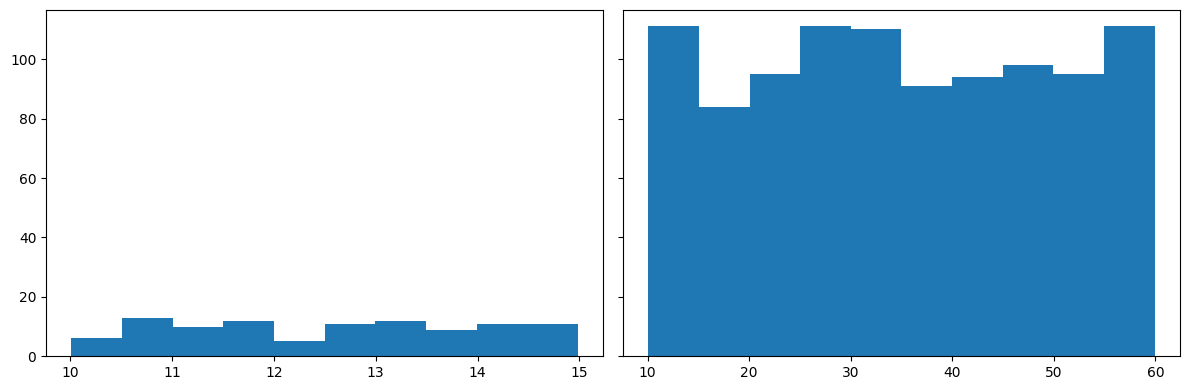

In [4]:
# 3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey="row")

ax1.hist(dist_1, bins=10)
ax2.hist(dist_2, bins=10)

plt.tight_layout()
plt.show()

How are the two distributions different?

In [5]:
# your answer below
# The two distributions look similar. They have different peaks and drops because of the randomness of the values, but overall look quite evenly distributed.
# Clearly, the second distribution has higher count because it has 10x the amount of samples.

## Normal Distribution

1. In the same way in the Uniform Distribution challenge, write a function that generates normally distributed random numbers.
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 1
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 50
2. Plot the distributions of the data generated.

Expected output:

![normal distribution](nd.png)

In [6]:
# 1
def gen_normal_dist(mean: float | int , std: float | int, count: int):
    """_summary_

    Args:
        mean (float): mean of the distribution
        std (float): standard deviation of the distribution
        count (int): number of samples
    """
    valid = [float, int]
    if type(mean) not in valid or type(mean) not in valid or type(count) != int:
        raise TypeError(f"Expected Int or Float. Got {type(mean)}, {type(std)}, {type(count)}")
    
    normal_dist = stats.norm(loc=mean, scale=std)
    
    return normal_dist.rvs(count)

In [7]:
norm_dist_1 = gen_normal_dist(10, 1, 1000)

In [8]:
norm_dist_2 = gen_normal_dist(10, 50, 1000)

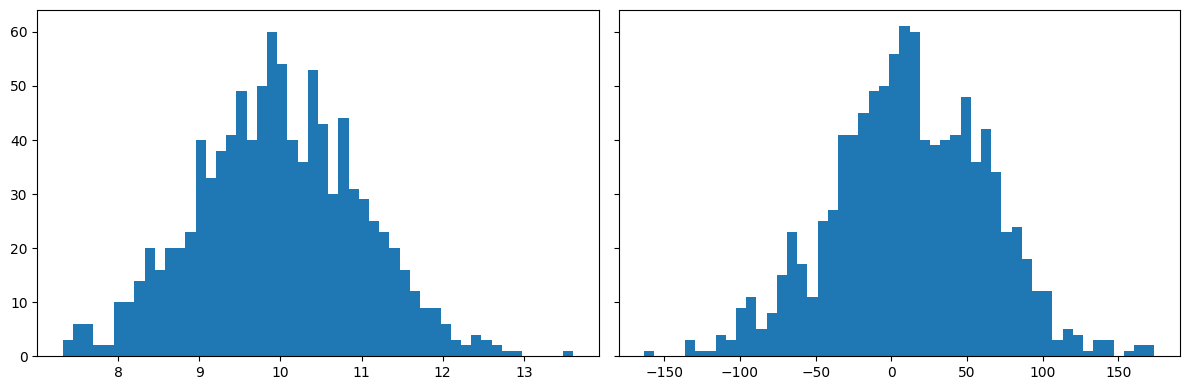

In [9]:
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4), sharey="row")

ax3.hist(norm_dist_1, bins=50)
ax4.hist(norm_dist_2, bins=50)

plt.tight_layout()
plt.show()

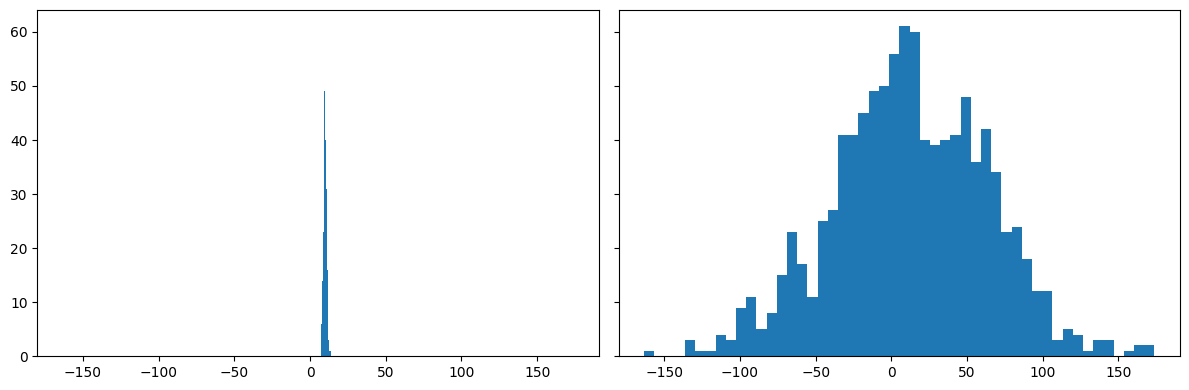

In [10]:
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4), sharey="row", sharex="row")

ax3.hist(norm_dist_1, bins=50)
ax4.hist(norm_dist_2, bins=50)

plt.tight_layout()
plt.show()

How are the two distributions different?

## Normal Distribution of Real Data

In this challenge we are going to take a look the real data. We will use vehicles.csv file for this exercise
First import vehicles.csv.

In [13]:
vehicles = pd.read_csv("./vehicles.csv")

In [15]:
vehicles.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


Then plot the histograms for the following variables:

1. Fuel Barrels/Year

In [61]:
barrels = vehicles["Fuel Barrels/Year"]

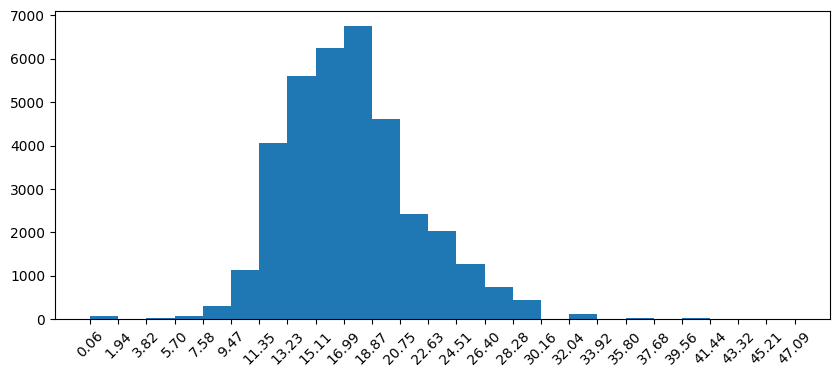

In [75]:
plt.figure(figsize=(10, 4))
_, bin_edges, _ = plt.hist(barrels, bins=25)
plt.xticks(bin_edges, rotation=45)
plt.show()

In [79]:
barrels.median()

np.float64(17.347894736842107)

In [ ]:
barrels.mean()

np.float64(17.609055502328133)

2. CO2 Emission Grams/Mile 

In [68]:
co2 = vehicles["CO2 Emission Grams/Mile"]

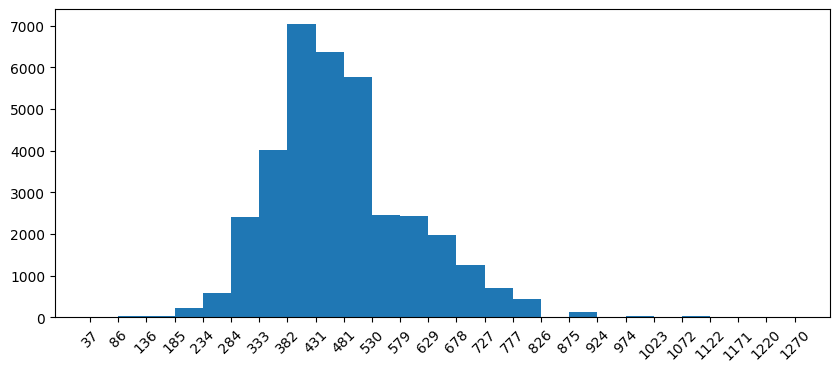

In [74]:
plt.figure(figsize=(10, 4))
_, bin_edges, _ = plt.hist(co2, bins=25)
plt.xticks(bin_edges, rotation=45)
plt.show()

In [78]:
co2.median()

np.float64(467.7368421052632)

In [57]:
co2.mean()

np.float64(475.3163392572124)

3. Combined MPG

In [70]:
mpg = vehicles["Combined MPG"]

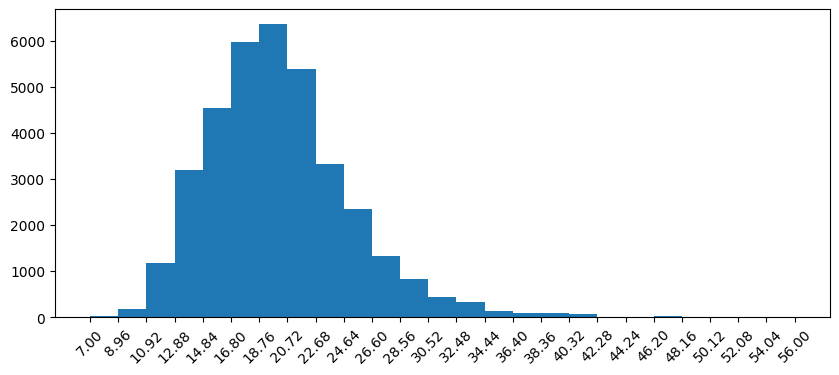

In [73]:
plt.figure(figsize=(10, 4))
_, bin_edges, _ = plt.hist(mpg, bins=25)
plt.xticks(bin_edges, rotation=45)
plt.show()

In [77]:
mpg.median()

np.float64(19.0)

In [72]:
mpg.mean()

np.float64(19.92932242990654)

Which one(s) of the variables are nearly normally distributed? How do you know?

-- your code here

None of them are normally distributed, even though the shape is close. They all have a slight left skew.
We can both visually assess this, and numerically. All medians are less than the mean.

## Exponential Distribution

1. Using `numpy.random.exponential`, create a function that returns a list of numbers exponentially distributed with the mean of 10. 

1. Use the function to generate two number sequences with the size of 10 and 100.

1. Plot the distributions as histograms with the nubmer of bins as 100.

Your output should look like below:

![exponential distribution](ed.png)

In [116]:
# your code here
def expo_gen(size: int, mean: float | int = 10):
    """_summary_

    Args:
        size (int): size of the distribution
        mean (float | int, optional): Mean of the distribution. Defaults to 10.
    """
    return np.random.exponential(scale=mean, size=size)

In [117]:
expo1 = expo_gen(size=10)
expo2 = expo_gen(size=100)

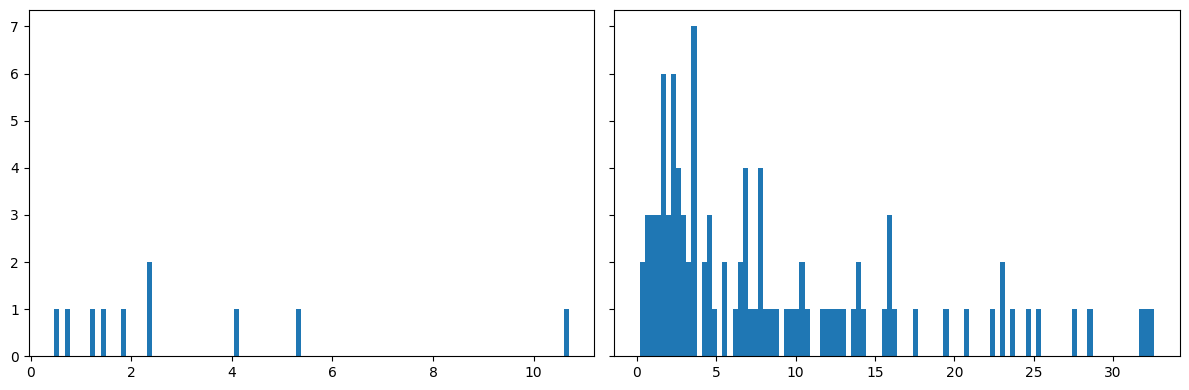

In [118]:
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(12, 4), sharey="row")

ax5.hist(expo1, bins=100)
ax6.hist(expo2, bins=100)

plt.tight_layout()
plt.show()

How are the two distributions different?

The distributions are very different. The first example does not have enough data for the exponentiation to kick in. The second starts to resemble an exponential distribution.

## Exponential Distribution of Real Data

Suppose that the amount of time one spends in a bank is exponentially distributed with mean as 10 minutes (i.e. λ = 1/10). What is the probability that a customer will spend less than fifteen minutes in the bank? 

Write a code in python to solve this problem

In [ ]:
# your code here
p_under15 = stats.expon.cdf(15, scale=10)

print(f"The probability that a customer will spend less than 15 minutes at the bank is:", p_under15.round(4))

The probability that a customer will spend less than 15 minutes at the bank is: 0.7769


What is the probability that the customer will spend more than 15 minutes

In [123]:
# your code here
p_over15 = stats.expon.sf(15, scale=10)

print(f"The probability that a customer will spend more than 15 minutes at the bank is:", p_over15.round(4))

The probability that a customer will spend more than 15 minutes at the bank is: 0.2231
